# Plotting Orientation with Pixel and World Axes

This notebook documents how a simple `(x, y)` marker behaves under:
1. Default matplotlib image plotting
2. `generate_plot` with **pixel axes**
3. `generate_plot` with **world (RA/Dec) axes**

The test image is a 20x20 grid with a single bright pixel written as `data[x, y] = data[5, 15]`.

The WCS is a mocked, standard equatorial celestial frame with `RA---SIN` and `DEC--SIN`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astroviper.utils.plotting import generate_plot

In [7]:
# Build a 20x20 image.
# The internal convention in this test is to write a source as data[x, y].
n_pix = 20
data = np.zeros((n_pix, n_pix), dtype=float)

# Requested marker location in astronomical (x, y) terms.
x_target = 5
y_target = 15
data[x_target, y_target] = 1.0

# Identify where that value appears in raw array row/column indexing.
# row -> vertical display coordinate, col -> horizontal display coordinate.
row_peak, col_peak = np.argwhere(data == data.max())[0]

print(f"Requested marker (x, y): ({x_target}, {y_target})")
print(f"Array write index: data[{x_target}, {y_target}]")
print(f"Raw row/col peak index: row={row_peak}, col={col_peak}")

Requested marker (x, y): (5, 15)
Array write index: data[5, 15]
Raw row/col peak index: row=5, col=15


In [8]:
# Mock a standard equatorial SIN WCS.
# RA has negative CDELT so longitude increases to the left on sky plots.
wcs = WCS(naxis=2)
wcs.wcs.crpix = [10.5, 10.5]
wcs.wcs.cdelt = np.array([-1.0 / 3600.0, 1.0 / 3600.0])  # deg/pixel
wcs.wcs.crval = [180.0, 30.0]  # reference RA/Dec in degrees
wcs.wcs.ctype = ["RA---SIN", "DEC--SIN"]
wcs.wcs.cunit = ["deg", "deg"]

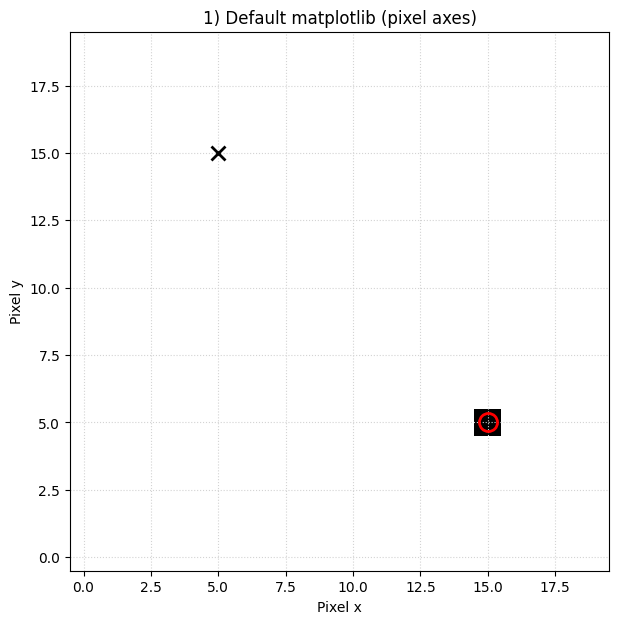

In [9]:
# Plot 1: Default matplotlib behavior (pixel coordinates on axes).
# This uses data as-is, so imshow interprets data[row, col].
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(data, origin="lower", interpolation="nearest", cmap="gray_r")

# Red circle: where the bright pixel is rendered.
ax.plot(col_peak, row_peak, "o", markersize=13, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)

# Black X: requested astronomical (x, y) input location.
ax.plot(x_target, y_target, "x", color="black", markersize=10, markeredgewidth=2)

ax.set_title("1) Default matplotlib (pixel axes)")
ax.set_xlabel("Pixel x")
ax.set_ylabel("Pixel y")
ax.set_xlim(-0.5, n_pix - 0.5)
ax.set_ylim(-0.5, n_pix - 0.5)
ax.grid(color="lightgray", linestyle=":", linewidth=0.8)
plt.show()

In [ ]:
# Plot 2: generate_plot with pixel-coordinate axes.
# The helper applies data.T so the display location matches the intended (x, y).
fig, ax = generate_plot(data, show_world_axes=False, cmap="gray_r", vmin=0, vmax=1)

# In the corrected orientation, the marker should appear at (x_target, y_target).
ax.plot(x_target, y_target, "o", markersize=13, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)
ax.plot(x_target, y_target, "x", color="black", markersize=10, markeredgewidth=2)

ax.set_title("2) generate_plot (pixel axes)")
ax.set_xlabel("Pixel x")
ax.set_ylabel("Pixel y")
ax.set_xlim(-0.5, n_pix - 0.5)
ax.set_ylim(-0.5, n_pix - 0.5)
ax.grid(color="lightgray", linestyle=":", linewidth=0.8)
plt.show()

In [ ]:
# Plot 3: generate_plot with world-coordinate axes (RA/Dec from WCS).
fig, ax = generate_plot(data, wcs=wcs, show_world_axes=True, cmap="gray_r", vmin=0, vmax=1)

# Mark the same source using pixel transform so marker is placed at pixel (x_target, y_target)
# but displayed on world-coordinate axes.
ax.plot(
    x_target,
    y_target,
    "o",
    markersize=13,
    markerfacecolor="none",
    markeredgecolor="red",
    markeredgewidth=2,
    transform=ax.get_transform("pixel"),
)

# Demonstrate RA direction numerically at the image midline.
y_mid = (n_pix - 1) / 2.0
ra_left_deg, dec_left_deg = wcs.all_pix2world(0.0, y_mid, 0)
ra_right_deg, dec_right_deg = wcs.all_pix2world(n_pix - 1.0, y_mid, 0)

print(f"Left-edge RA  (deg): {ra_left_deg:.8f}")
print(f"Right-edge RA (deg): {ra_right_deg:.8f}")
print("RA increases to the left:", ra_left_deg > ra_right_deg)

ax.set_title("3) generate_plot (world RA/Dec axes)")
ax.coords[0].set_axislabel("Right Ascension (deg)")
ax.coords[1].set_axislabel("Declination (deg)")
ax.coords.grid(color="lightgray", linestyle=":", linewidth=0.8)

# Visual cue for expected astronomical handedness.
ax.text(
    0.03,
    0.97,
    "East / increasing RA \u2190",
    transform=ax.transAxes,
    ha="left",
    va="top",
    color="white",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.55, edgecolor="none"),
)

plt.show()